In [1]:
import numpy as np 
import astropy.units as units
from astropy.time import Time 
from astropy.constants import G
import matplotlib
import matplotlib.pyplot as plt 
%matplotlib inline
import cloudpickle
import exoplanet as xo 
import sys 
sys.path.append("helpers")

import data 
import xo_archive
import fit
import plots


from scipy.stats import norm 
from importlib import reload

xo.utils.docs_setup()
import lightkurve as lk 

import pymc3 as pm
import pymc3_ext as pmx
#import theano.tensor as tt
import aesara_theano_fallback.tensor as tt
tt.config.exception_verbosity = 'high'
from celerite2.pymc3 import terms, GaussianProcess
import arviz as az
import corner
import forecaster

matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
planet_parameters = xo_archive.get_exoplanet_parameters("Kepler-62 ", which="composite")
param_lists = xo_archive.transpose_parameters(planet_parameters)

search_results = lk.search_lightcurve("Kepler-62", mission="Kepler", exptime=1800)
lcc = search_results.download_all()
lc = lcc.stitch().remove_nans()

In [3]:
param_lists

{'pl_name': ['Kepler-62 b',
  'Kepler-62 c',
  'Kepler-62 d',
  'Kepler-62 e',
  'Kepler-62 f'],
 'pl_letter': ['b', 'c', 'd', 'e', 'f'],
 'pl_orbper': [5.714932, 12.4417, 18.16406, 122.3874, 267.291],
 'pl_orbsmax': [0.0553, 0.0929, 0.12, 0.427, 0.718],
 'pl_orbincl': [89.2, 89.7, 89.7, 89.98, 89.9],
 'pl_orbeccen': [0.0, 0.0, 0.0, 0.0, 0.0],
 'pl_trandep': [0.043, 0.007, 0.092, 0.07, 0.042],
 'pl_tranmid': [2455003.9189,
  2454967.651,
  2455013.8117,
  2454983.404,
  2455422.71],
 'pl_trandur': [2.31, 3.02, 2.97, 6.92, 7.46],
 'pl_ratror': [0.0188, 0.0077, 0.0278, 0.0232, 0.0203],
 'pl_imppar': [0.25, 0.16, 0.22, 0.06, 0.41],
 'st_rad': [0.64, 0.64, 0.64, 0.64, 0.64],
 'st_mass': [0.69, 0.69, 0.69, 0.69, 0.69],
 'st_dens': [3.8, 3.8, 3.8, 3.8, 3.8],
 'gaia_dr3_id': ['Gaia DR3 2107001283431633408',
  'Gaia DR3 2107001283431633408',
  'Gaia DR3 2107001283431633408',
  'Gaia DR3 2107001283431633408',
  'Gaia DR3 2107001283431633408'],
 'pl_rade': [1.31, 0.54, 1.95, 1.61, 1.41],
 'pl_ra

(0.995, 1.005)

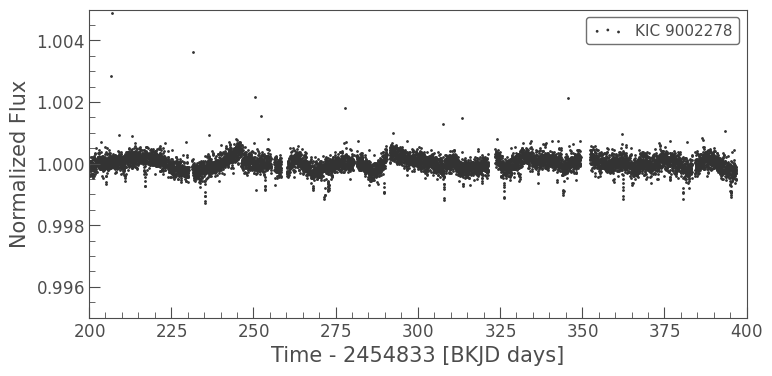

In [4]:
lc.scatter()
plt.xlim(200,400)
plt.ylim(0.995,1.005)

In [5]:
model, difference, std_calculated, mean_tweaked = data.model_data_residuals(param_lists, lc)
lc_final, flags_5sigma = data.remove_outliers(5, lc, difference, std_calculated, mean_tweaked) 

In [6]:
transit_mask = lc_final.create_transit_mask(period=param_lists['pl_orbper']*units.day, 
                                            transit_time=(Time(param_lists["pl_tranmid"],format="jd")), 
                                            duration=param_lists['pl_trandur']*units.hour)

notransits = lc_final[~transit_mask]
transits = lc_final[transit_mask]

In [7]:
transit_windows_mask = fit.create_transit_windows(lc_final, period=param_lists['pl_orbper']*units.day, 
                                            transit_time=(Time(param_lists["pl_tranmid"],format="jd")), 
                                            duration=param_lists['pl_trandur']*units.hour)

transit_windows = lc_final[transit_windows_mask]

In [8]:
def diagnostic_plots(lc, lc_final, transits, transit_windows, param_lists, model, difference, std_calculated, mean_tweaked, sigma, flags_nsigma):
    
    # Model/data comparison plot
    p = lc.scatter()
    plt.close()
    fig, ax = plt.subplots(figsize=(12,6))
    plt.plot(lc.time.value,lc.flux.value,color='k',marker='o',ls='',label='data')
    plt.plot(lc.time.value,difference,marker='o',ls='',color='green',label='difference')
    plt.plot(lc.time.value, model+1,color='orange',lw=3,label='model')
    plt.xlabel(p.get_xlabel())
    plt.ylabel(p.get_ylabel())
    plt.xlim(min(lc.time.value), min(lc.time.value)+100)
    plt.ylim(mean_tweaked-(10*std_calculated), mean_tweaked+(10*std_calculated))
    plt.legend(loc='lower left',fontsize=12)
    plt.show()
    
    # Cumulative distribution function plot
    fig, ax = plt.subplots()
    diff_sorted = np.sort(1-difference)
    norm_cdf = norm.cdf((diff_sorted - (1 - mean_tweaked))/std_calculated)
    N = len(diff_sorted)
    p = np.arange(N)
    plt.plot(p, diff_sorted,label='residuals',color='deeppink',zorder=1)
    plt.plot(norm_cdf*N, diff_sorted, label='gaussian',color='k',zorder=0)
    plt.ylim(1-mean_tweaked-5*std_calculated, 1-mean_tweaked+5*std_calculated)
    #plt.axhline(1-mean_tweaked,color='k')
    plt.axhline(1-mean_tweaked-std_calculated,color='k',ls='dashed')
    plt.axhline(1-mean_tweaked+std_calculated,color='k',ls='dashed')
    plt.xlabel("Frequency")
    plt.ylabel("Flux")
    plt.legend(fontsize=12)
    #plt.savefig('output/Kepler-62/long/Kepler-62_plots/diagnostic_plots/K62-cdf.jpg', dpi=300, bbox_inches="tight")
    
    # Residuals histogram plot
    fig, ax = plt.subplots()
    if np.log10(len(lc.time)) >= 6: 
        bins_number = 20000
    elif 5 < np.log10(len(lc.time)) < 6: 
        bins_number = 10000
    else:
        bins_number = 1000
    h, bins = np.histogram(1-difference, bins=bins_number)
    plt.hist(1-difference, bins=bins, density=True,color='cornflowerblue')
    plt.plot(bins, norm(1-mean_tweaked, std_calculated).pdf(bins), linewidth=2, color='black',label='gaussian')
    plt.axvline(1-mean_tweaked-(sigma*std_calculated),ls='dashed',color='k')
    plt.axvline(1-mean_tweaked+(sigma*std_calculated),ls='dashed',color='k',label="{0}-sigma".format(sigma))
    plt.ylim(1e-6,1e4)
    plt.xlim(1-mean_tweaked-(10*std_calculated), 1-mean_tweaked+(10*std_calculated))
    plt.yscale('log')
    plt.xlabel("Residuals")
    plt.ylabel("Probability")
    plt.legend(fontsize=12,loc='upper right')
    #plt.savefig('output/Kepler-62/long/Kepler-62_plots/diagnostic_plots/K62-histogram.jpg', dpi=300, bbox_inches="tight")
    
    # Highlighting outliers plot
    fig, ax = plt.subplots(figsize=(10,4))
    plt.scatter(lc.time.value, lc.flux.value,color='k',label='data',s=0.5,alpha=0.5)
    plt.plot(lc.time.value, model+1,color='deeppink',label='model')
    plt.scatter(lc.time.value[flags_nsigma], lc.flux.value[flags_nsigma],label='{0}-sigma outliers'.format(sigma),color='blue')
    plt.ylim(mean_tweaked-(10*std_calculated), mean_tweaked+(10*std_calculated))
    plt.xlim(min(lc.time.value), min(lc.time.value)+200)
    plt.xlabel("Time [BKJD]")
    plt.ylabel("Normalized flux")
    plt.legend(fontsize=10,loc='lower right')
    #plt.savefig('K62-outliers.jpg', dpi=300, bbox_inches="tight")
    
    # Outlier distribution plot
    fig, ax = plt.subplots()
    plt.scatter(difference[flags_nsigma],model[flags_nsigma],label='outliers',color='k')
    plt.xlabel("difference")
    plt.ylabel("model")
    plt.legend(fontsize=12)
    plt.show()
    
    # Phase folded light curves plot
    fig, ax = plt.subplots(len(param_lists['pl_letter']), figsize=(12,20))
    with plt.style.context(lk.MPLSTYLE):
        for i, letter in enumerate(param_lists['pl_letter']):
            if lc.time.format == 'bkjd':
                epoch_time = Time(param_lists["pl_tranmid"][i],format="jd").bkjd
            elif lc.time.format == 'btjd':
                epoch_time = Time(param_lists["pl_tranmid"][i],format="jd").btjd
            else: 
                epoch_time = None
                print('error. could not identify time system used for light curve (e.g., BKJD or BTJD)')
            ax[i] = lc_final.fold(period=param_lists["pl_orbper"][i],
                               epoch_time=epoch_time).scatter(ax=ax[i], label=param_lists["pl_name"][i], alpha=0.04, color='k')
            ax[i].get_legend().remove()
            ax[i].set_xlabel('Time since transit (days)')
            ax[i].set_title('Planet '+ str(letter),fontsize=20)
        plt.tight_layout()
        #plt.savefig('output/Kepler-62/long/Kepler-62_plots/diagnostic_plots/K62-folded.jpg', dpi=300, bbox_inches="tight")
    
    # Transit windows plot 
    plt.figure(figsize=(10,4))
    plt.scatter(lc_final.time.value, lc_final.flux.value, label='data')
    plt.scatter(transit_windows.time.value, transit_windows.flux.value, label='transit windows')
    plt.scatter(transits.time.value, transits.flux.value, label='transits')
    plt.plot(lc.time.value, model+1, label='model', color='k')
    plt.xlim(min(lc_final.time.value), min(lc_final.time.value)+20)
    plt.legend(fontsize=10,loc='lower left')
    plt.show()

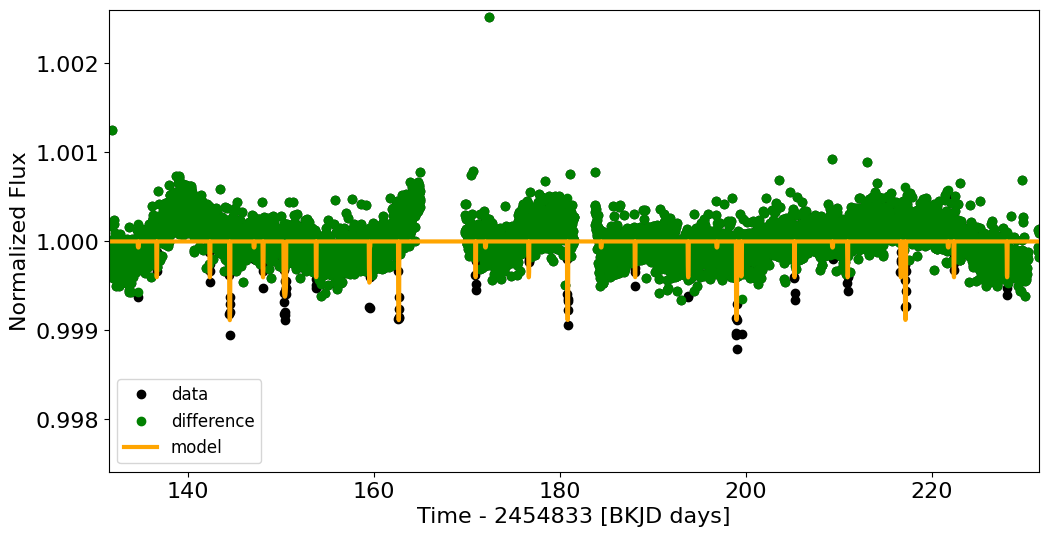

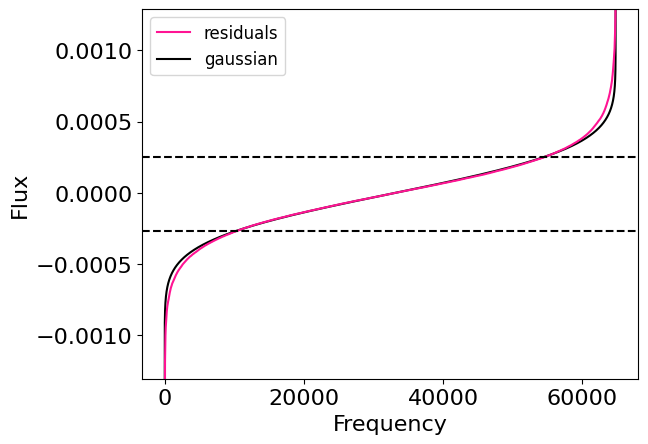

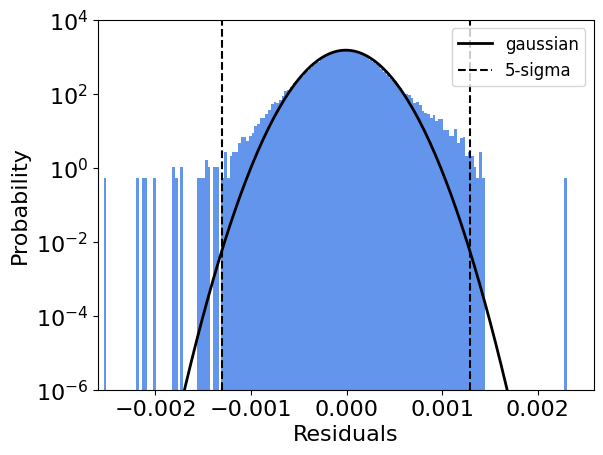

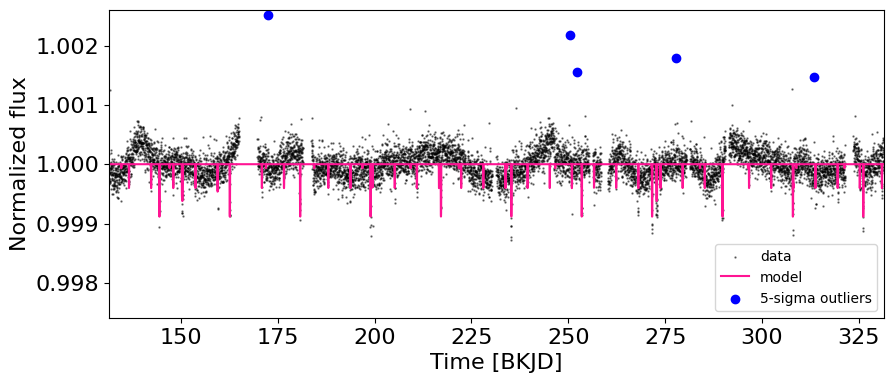

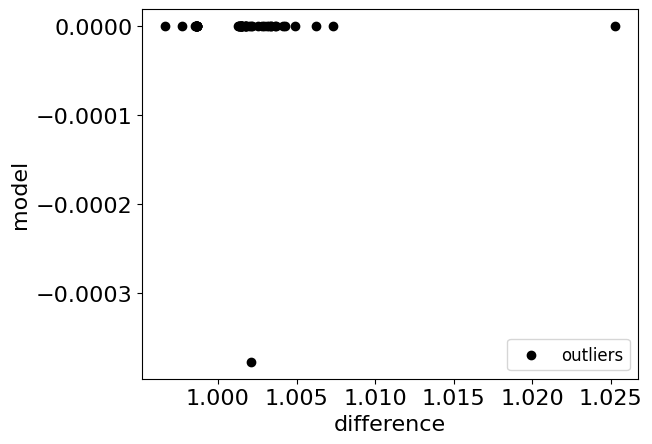

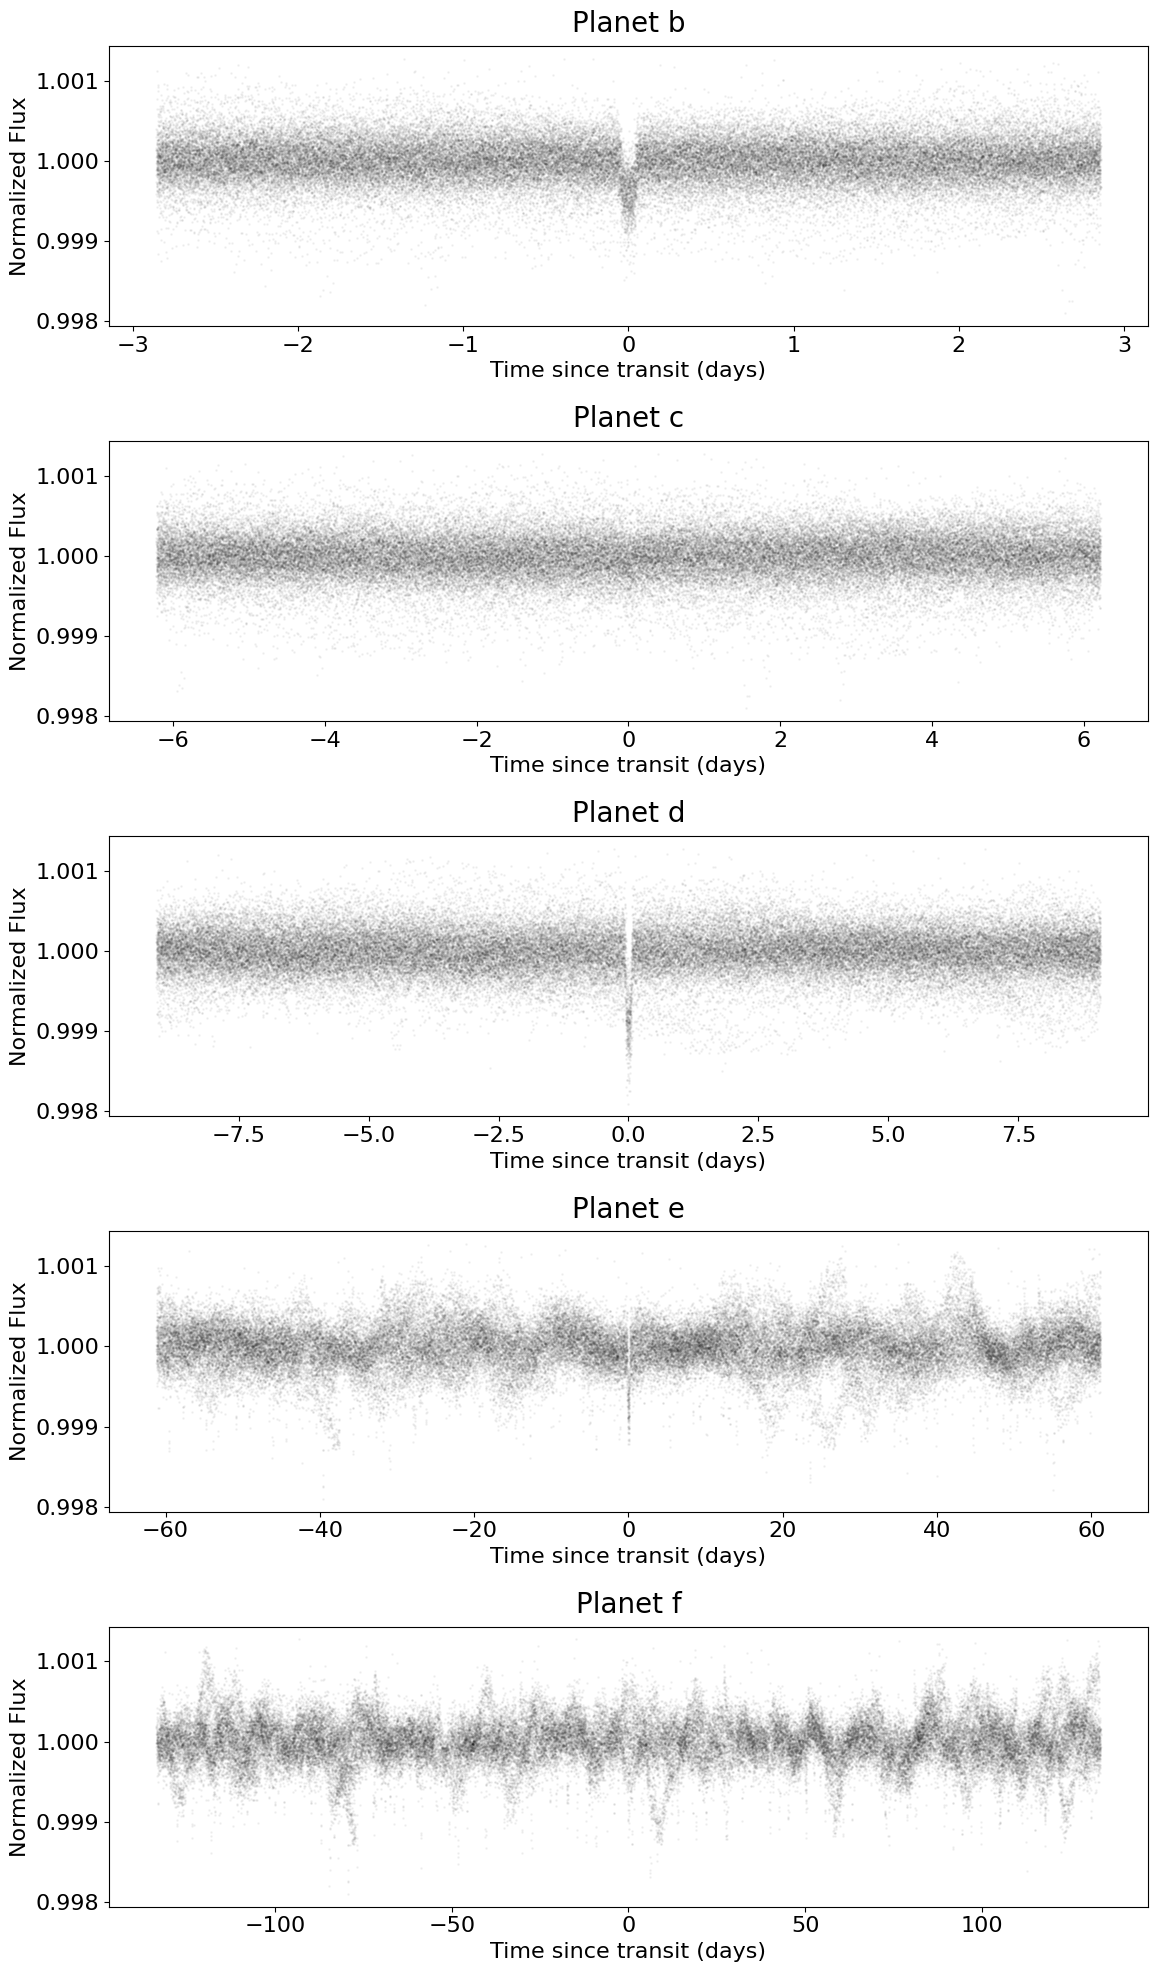

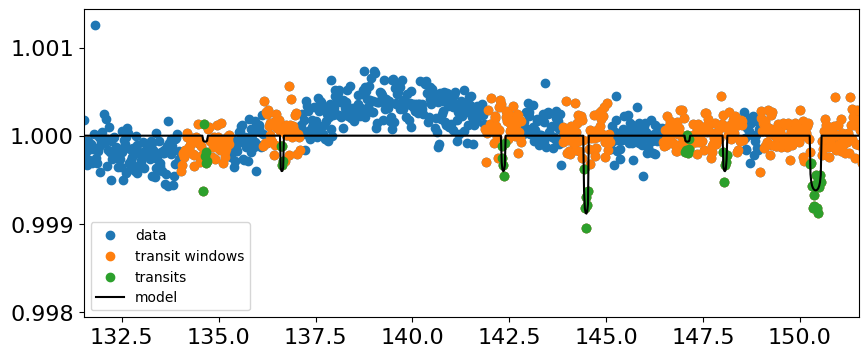

In [9]:
diagnostic_plots(lc, lc_final, transits, transit_windows, param_lists, model, difference, std_calculated, mean_tweaked, sigma=5, flags_nsigma=flags_5sigma)


In [10]:
def gp(lc, param_lists, complicated_gp=False):

    with pm.Model() as model:

        # Gaussian process 
        if complicated_gp == True: 
            
            # A jitter term describing excess white noise
            log_jitter = pm.Normal("log_jitter", mu=np.log(np.mean(lc['flux_err'])), sd=2)
            
            # A term to describe the non-periodic variability
            log_sigma_1 = pm.Normal("log_sigma_1", mu=np.log(np.mean(lc['flux_err'])), sd=10)
            log_rho_1 = pm.Normal("log_rho_1", mu=np.log(1), sd=np.log(10))  
            log_Q_1 = pm.Normal("log_Q_1", mu=np.log(2), sd=np.log(2))
            
            log_sigma_2 = pm.Normal("log_sigma_2", mu=np.log(np.mean(lc['flux_err'])), sd=10)
            log_rho_2 = pm.Normal("log_rho_2", mu=np.log(1), sd=np.log(2))  
            log_Q_2 = pm.Normal("log_Q_2", mu=np.log(2), sd=np.log(2))
    
            # The parameters of the RotationTerm kernel
            """peak = plots.periodogram_lomb_scargle(lc)
            sigma_rot = pm.InverseGamma("sigma_rot", **pmx.estimate_inverse_gamma_parameters(1.0, 5.0))
            log_prot = pm.Normal("log_prot", mu=np.log(peak["period"]), sd=0.02)
            log_Q0 = pm.Normal("log_Q0", mu=0, sd=2)
            log_dQ = pm.Normal("log_dQ", mu=0, sd=2)
            f = pm.Uniform("f", lower=0.01, upper=1.0)"""
            
            # Set up the Gaussian Process model
            
            kernel = terms.SHOTerm(sigma=tt.exp(log_sigma_1), rho=tt.exp(log_rho_1), Q=tt.exp(log_Q_1))  
            
            kernel += terms.SHOTerm(sigma=tt.exp(log_sigma_2), rho=tt.exp(log_rho_2), Q=tt.exp(log_Q_2))  
            
            """kernel += terms.RotationTerm( 
                sigma=sigma_rot,
                period=tt.exp(log_prot),
                Q0=tt.exp(log_Q0),
                dQ=tt.exp(log_dQ),
                f=f)"""
            
            gaussian_vars = [log_jitter, log_sigma_1, log_rho_1, log_Q_1, log_sigma_2, log_rho_2, log_Q_2]
            #gaussian_vars = [log_jitter, log_sigma_gp, log_rho_gp, log_Q, sigma_rot, log_prot, log_Q0, log_dQ, f]
                
        else: 
            # A jitter term describing excess white noise
            log_jitter = pm.Normal("log_jitter", mu=np.log(np.mean(lc['flux_err'])), sd=2)
    
            # The standard deviation of the process
            # defined as sqrt(S0 * w0 * Q)
            # where S0 is related to the power when w = 0 
            # and w0 is the undamped angular frequency
            log_sigma_gp = pm.Normal("log_sigma_gp", mu=np.log(np.mean(lc['flux_err'])), sd=10)
        
            # the undamped period of the oscillator
            # 2pi / w0 
            log_rho_gp = pm.Normal("log_rho_gp", mu=np.log(15), sd=np.log(10)) # in days, constrain a little bit 
        
            log_Q = pm.Normal("log_Q", mu=np.log(2), sd=np.log(2)) # make larger 
    
            # GP model for the light curve
            kernel = terms.SHOTerm(sigma=tt.exp(log_sigma_gp),
                               rho=tt.exp(log_rho_gp),
                               Q=tt.exp(log_Q))
            
            gaussian_vars = [log_jitter, log_sigma_gp, log_rho_gp, log_Q]
            
        
        t = np.array(lc['time'].value)
        err = np.array(lc['flux_err'].value)
        gp = GaussianProcess(kernel, 
                             t=t, 
                             diag=lc['flux_err'].value**2 + tt.exp(2*log_jitter), 
                             quiet=False)
        
        gp.marginal("transit_obs", observed=lc['flux'].value - np.mean(lc['flux'].value))
        pm.Deterministic("gp_pred", gp.predict(lc['flux'].value - np.mean(lc['flux'].value)))
        
        freq = np.linspace(0.01,10,5000)
        pm.Deterministic("psd", kernel.get_psd(freq))
        
        # Optimize the MAP solution
        
        start = model.test_point

        map_soln = start
        map_soln = pmx.optimize(start=map_soln, vars=gaussian_vars[:len(gaussian_vars)//2]) 
        #map_soln = pmx.optimize(start=map_soln, vars=gaussian_vars[:len(gaussian_vars)//2+2]) 
        #map_soln = pmx.optimize(start=map_soln, vars=gaussian_vars[:len(gaussian_vars)//2+3]) 
        map_soln = pmx.optimize(start=map_soln, vars=gaussian_vars[len(gaussian_vars)//2:]) 
        map_soln = pmx.optimize(start=map_soln)
    
    return map_soln

In [11]:
gp_map_soln = gp(notransits, param_lists, complicated_gp=True)

optimizing logp for variables: [log_rho_1, log_sigma_1, log_jitter]


message: Desired error not necessarily achieved due to precision loss.
logp: 443270.41459138726 -> 451285.5772730996
optimizing logp for variables: [log_Q_2, log_rho_2, log_sigma_2, log_Q_1]


message: Desired error not necessarily achieved due to precision loss.
logp: 451285.5772730996 -> 453208.5504424124
optimizing logp for variables: [log_Q_2, log_rho_2, log_sigma_2, log_Q_1, log_rho_1, log_sigma_1, log_jitter]


message: Desired error not necessarily achieved due to precision loss.
logp: 453208.5504424124 -> 453211.7680572161


plots.plot_psd(gp_map_soln)

In [12]:
gp_map_soln

{'log_jitter': array(-9.64337049),
 'log_sigma_1': array(-8.38806971),
 'log_rho_1': array(2.57438691),
 'log_Q_1': array(0.62726598),
 'log_sigma_2': array(-9.69757331),
 'log_rho_2': array(-0.57895062),
 'log_Q_2': array(-1.93555454),
 'gp_pred': array([-9.02989191e-05, -9.37095048e-05, -9.74853829e-05, ...,
         1.07171954e-04,  1.03629857e-04,  1.00661382e-04]),
 'psd': array([4.79845285e-08, 4.79996737e-08, 4.80175790e-08, ...,
        4.89536153e-11, 4.89341371e-11, 4.89146703e-11])}

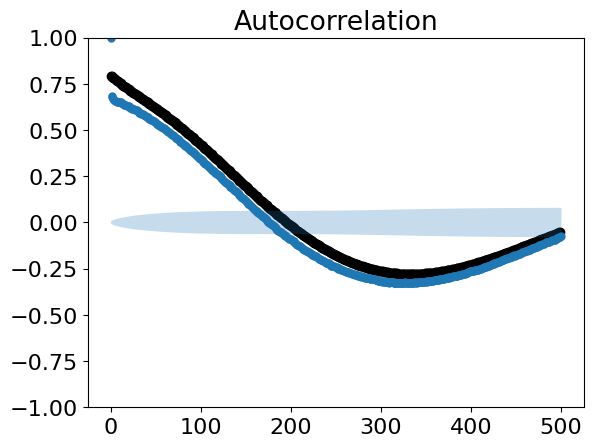

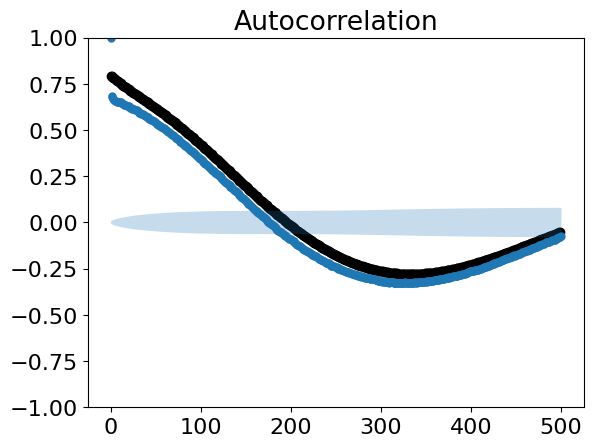

In [13]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

lags = 500

# SHO term 1 (Q > 1/2)

jitter = np.exp(gp_map_soln['log_jitter'])
sigma = np.exp(gp_map_soln['log_sigma_1'])
rho = np.exp(gp_map_soln['log_rho_1']) 
Q = np.exp(gp_map_soln['log_Q_1']) 
cadence_offset = np.linspace(0, lags-1, lags)
tau = cadence_offset*0.0204166667
w0 = 2*np.pi / rho 
eta = np.sqrt(np.abs(1 - (1/(4*Q**2))))

jitter_contribution = jitter**2 + np.mean(notransits['flux_err'])**2
sho_kernel_1 = sigma**2 / (sigma**2 + jitter_contribution) * np.exp(-w0 * tau / (2*Q)) * (np.cos(eta * w0 * tau) + 1/(2*eta*Q)*np.sin(eta * w0 * tau))

# SHO term 1 (Q < 1/2)

sigma = np.exp(gp_map_soln['log_sigma_2'])
rho = np.exp(gp_map_soln['log_rho_2']) 
Q = np.exp(gp_map_soln['log_Q_2'])
w0 = 2*np.pi / rho 
eta = np.sqrt(np.abs(1 - (1/(4*Q**2))))

sho_kernel_2 = sigma**2 / (sigma**2 + jitter_contribution) * np.exp(-w0 * tau / (2*Q)) * (np.cosh(eta * w0 * tau) + 1/(2*eta*Q)*np.sinh(eta * w0 * tau))

kernel = sho_kernel_1 + sho_kernel_2

fig, ax = plt.subplots()
ax.scatter(cadence_offset, kernel, color='black')
#acf_quarter = acf(lc_i['flux'] - np.mean(lc_i['flux']), nlags=499, missing='conservative')
#ax.scatter(cadence_offset, acf_quarter - np.mean(acf_quarter[10:20]))
plot_acf(notransits['flux'] - np.mean(notransits['flux']), lags=lags, use_vlines=False, ax=ax, missing='conservative')
#ax.set_xlim(0,50)
#ax.set_ylim(0.1,1)


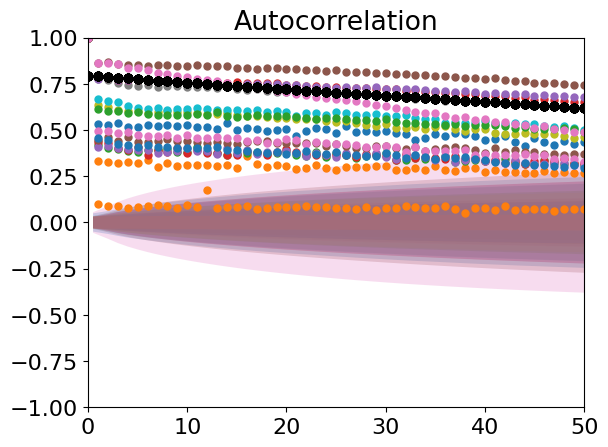

In [14]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

fig, ax = plt.subplots()

# clean up outliers before 
for i in range(17):
    lc_i = lcc[i].remove_nans()
    transit_mask = lc_i.create_transit_mask(period=param_lists['pl_orbper']*units.day, 
                                            transit_time=(Time(param_lists["pl_tranmid"],format="jd")), 
                                            duration=param_lists['pl_trandur']*units.hour)
    lc_i = lc_i[~transit_mask]

    # how is plot_Acf function handling gaps in data 
    # overplot kernel 
    lags = 500
    
    jitter = np.exp(gp_map_soln['log_jitter'])
    
    # SHO term 1 (Q > 1/2)
    sigma = np.exp(gp_map_soln['log_sigma_1'])
    rho = np.exp(gp_map_soln['log_rho_1']) 
    Q = np.exp(gp_map_soln['log_Q_1']) 
    cadence_offset = np.linspace(0, lags-1, lags)
    tau = cadence_offset*0.0204166667
    w0 = 2*np.pi / rho 
    eta = np.sqrt(np.abs(1 - (1/(4*Q**2))))

    jitter_contribution = jitter**2 + np.mean(notransits['flux_err'])**2
    sho_kernel_1 = sigma**2 / (sigma**2 + jitter_contribution) * np.exp(-w0 * tau / (2*Q)) * (np.cos(eta * w0 * tau) + 1/(2*eta*Q)*np.sin(eta * w0 * tau))
    
    # SHO term 2 (Q < 1/2)
    sigma = np.exp(gp_map_soln['log_sigma_2'])
    rho = np.exp(gp_map_soln['log_rho_2']) 
    Q = np.exp(gp_map_soln['log_Q_2'])
    w0 = 2*np.pi / rho 
    eta = np.sqrt(np.abs(1 - (1/(4*Q**2))))

    sho_kernel_2 = sigma**2 / (sigma**2 + jitter_contribution) * np.exp(-w0 * tau / (2*Q)) * (np.cosh(eta * w0 * tau) + 1/(2*eta*Q)*np.sinh(eta * w0 * tau))

    kernel = sho_kernel_1 + sho_kernel_2
    
    ax.scatter(cadence_offset, kernel, color='black',zorder=18)
    #acf_quarter = acf(lc_i['flux'] - np.mean(lc_i['flux']), nlags=499, missing='conservative')
    #ax.scatter(cadence_offset, acf_quarter - np.mean(acf_quarter[10:20]))
    plot_acf(lc_i['flux'] - np.mean(lc_i['flux']), lags=lags, use_vlines=False, ax=ax, missing='conservative')
    ax.set_xlim(0,50)
    #ax.set_ylim(-0.1,)


In [15]:
def plot_fittedlightcurves(lc_final, param_lists, map_soln):

    t = lc_final["time"].value
    y = lc_final["flux"].value
    gp_mod = map_soln["gp_pred"] + map_soln["mean"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    
    # plotting gp_model against data 
    ax = axes[0]
    ax.plot(t, y, "k", label="data")
    ax.plot(t, gp_mod, color="C2", label="gp model")
    ax.legend(fontsize=10)
    ax.set_ylabel("relative flux")

    # plotting de-trended data 
    ax = axes[1]
    ax.plot(t, y - gp_mod, "k", label="de-trended data")
    for i, l in enumerate(param_lists['pl_letter']):
        ax.plot(t, map_soln["light_curves"][:, i], label="planet {0}".format(l))
    ax.legend(fontsize=10, loc=3)
    ax.set_ylabel("de-trended flux [ppt]")
    
    # plotting residuals 
    ax = axes[2]
    mod = gp_mod + np.sum(map_soln["light_curves"], axis=-1)
    rms = np.sqrt(np.median((y-mod)**2))
    mask = np.abs(y-mod) < 7 * rms
    ax.plot(t, y - mod, "k")
    plt.plot(t[~mask], (y-mod)[~mask], "xr", label="outliers")
    ax.axhline(0, color="#aaaaaa", lw=1)
    ax.set_ylabel("residuals [ppt]")
    
    plt.xlim(min(t), min(t)+200)
    plt.xlabel("time [days]")
    plt.tight_layout()

    return fig, mask 


def folded_plots(lc_final, param_lists, map_soln):
    detrended_data = lk.LightCurve(time=lc_final['time'], flux=lc_final['flux']-map_soln["gp_pred"])
    gp_model = lk.LightCurve(time=lc_final['time'], flux=map_soln['gp_pred']+map_soln['mean'])
    for n, letter in enumerate(param_lists['pl_letter']):

        model = lk.LightCurve(time=lc_final['time'], flux=map_soln["light_curves"][:,n]+map_soln['mean'])
    
        fig, ax = plt.subplots(figsize=(12,4))
        lc_final.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).scatter(ax=ax, alpha=1, label='raw data',color='cadetblue',s=20)
        detrended_data.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).scatter(ax=ax, label='stellar variability removed', color='orange',s=20)
        #gp_model.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).scatter(ax=ax, label='gp model')
        model.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).plot(ax=ax,color='k',lw=2,label='best fit model')
        plt.xlim(-0.5,0.5)
        #ax.legend().remove()
        plt.title('planet '+ str(letter),fontsize=20)
        plt.annotate("radius = {0:.4f} R$_\oplus$".format(map_soln['r_p'][n]*units.solRad.to(units.earthRad)),(0.78, -0.05),xycoords="axes fraction",xytext=(7,25),textcoords="offset points",va="top",ha="left",fontsize=15)
        plt.tight_layout()

In [16]:
def optimize_model(lc, initial_guesses, gp_map_soln, texp=0.5 / 24, u_init=[0.3, 0.2], start=None, use_mass=True, log_density=False, impact_param=True, include_depth=True, log_depth=True, complicated_gp=False):
    """Optimize a transit model to fit some data

    Parameters
    ----------
    lc : :class:`~lightkurve.Lightcurve`
        The lightcurve data
    initial_guesses : `dict`
        Dictionary of initial guesses
    texp : `float`, optional
        Exposure time, by default 0.5/24
    u_init : `list`, optional
        Initial limb darkening guesses, by default [0.3, 0.2]

    Returns
    -------
    model
        PyMC3 model
    map_soln : `dict`
        Dictionary of optimized parameters
    """
    n_planets = len(initial_guesses["pl_orbper"])
    t0s_bkjd = Time(initial_guesses["pl_tranmid"], format="jd").bkjd
    mass_star = np.array(initial_guesses['berger_mass'])[0]
    depths = np.array(initial_guesses['pl_trandep'])/100

    with pm.Model() as model:

        # The baseline flux
        mean = pm.Normal("mean", mu=1.0, sd=1.0) 

        # The time of a reference transit for each planet
        t0 = pm.Normal("t0", mu=t0s_bkjd, sd=1.0, shape=n_planets)

        # The log period; also tracking the period itself
        logP = pm.Normal("logP", mu=np.log(initial_guesses["pl_orbper"]), sd=0.1, shape=n_planets)
        period = pm.Deterministic("period", tt.exp(logP))

        # The Kipping (2013) parameterization for quadratic limb darkening parameters
        # An uninformative prior for quadratic limb darkening parameters, flat distribution 
        # u1 (scalar) – The first limb darkening coefficient
        # u2 (scalar) – The second limb darkening coefficient
        u = xo.distributions.QuadLimbDark("u", testval=u_init)
        model_lightcurve = xo.LimbDarkLightCurve(u[0], u[1])
        
        # stellar density 
        initial_dens = initial_guesses["st_dens"][0] if initial_guesses["berger_dens"][0] == -1.0\
            else initial_guesses["berger_dens"][0]
        
        if log_density == True:
            print('drawing lognormal prior for stellar density')
            log_rho_star = pm.Normal("log_rho_star",mu=np.log(initial_dens), sd=1)
            rho_star = pm.Deterministic("rho_star", tt.exp(log_rho_star))
            
            system_vars = [log_rho_star]
            
        else: 
            print('drawing normal prior for stellar density')
            rho_star = pm.Normal("rho_star",mu=initial_dens, sd=1)
            xo.units.with_unit(rho_star, (units.g/(units.cm**3)))
            
            system_vars = [rho_star]
        
        # calculating the stellar radius from density and mass 
        if use_mass == True: 
            print('calculating the stellar radius from density and mass')
            r_star = pm.Deterministic("r_star", (((mass_star/rho_star)/((4/3)*np.pi))**(1/3)) * ((units.solMass / (units.g/units.cm**3))**(1/3)).to(units.solRad))

        else: 
            print('drawing normal distribution prior for stellar radius')
            r_star = pm.Normal("r_star", mu=initial_guesses["st_rad"][0], sd=0.1)
            system_vars.extend([r_star])
            
            
        # Let the eccentricity float, and use the eccentricity distribution
        # from https://arxiv.org/abs/1807.00549 as our prior 
        # ecs = pmx.UnitDisk("ecs", testval=0.1*np.ones((2, n_planets)), shape=(2, n_planets))
        # ecc = pm.Deterministic("ecc", tt.sum(ecs**2, axis=0))
        # omega calc from e_x and e_y 
        # omega = pm.Deterministic("omega", tt.arctan2(ecs[1], ecs[0])) 
        # sigma_ecc = pm.Uniform("sigma_ecc", lower=0, upper=1)
        
        #ecc = pm.HalfNormal('ecc', sigma=0.083, shape=n_planets)
        #ecc = xo.eccentricity.vaneylen19("ecc", multi=True, shape=n_planets, fixed=True)
        #omega = np.zeros(n_planets) 
        
        #xo.eccentricity.vaneylen19("ecc_prior", multi=True, shape=n_planets, fixed=True, observed=ecc)
        # Alternative choice:
        #xo.eccentricity.kipping13("ecc_prior", fixed=True, observed=ecc, shape=n_planets)
        #system_vars.extend([ecc]) 
        
        """
        amd 
        """
        
        if impact_param == True:
            print('using impact parameter')

            if include_depth == True:
                print('calculating ror from depth and uniform distribution of b')
            
                if log_depth == True: 
                    print('drawing log normal prior for transit depth')
                    log_depth = pm.Normal("log_depth", mu=np.log(depths), sd=1.0, shape=n_planets)
                    depth = pm.Deterministic("depth", tt.exp(log_depth))
                
                    system_vars.append(log_depth)
                
                else: 
                    print('drawing normal prior for transit depth')
                    depth = pm.Normal("depth", mu=depths, sd=2.0, shape=n_planets)
                
                    system_vars.append(depth)
            
                b = pm.Uniform("b", lower=0, upper=1, shape=n_planets, testval=initial_guesses["pl_imppar"])
        
                ror = pm.Deterministic("ror", model_lightcurve.get_ror_from_approx_transit_depth(depth, b))
                        
            else:
                print('calculating b from uniform distribution of ror')
                ror = pm.Uniform("ror", lower=0.001, upper=0.1, shape=n_planets, testval=initial_guesses["pl_ratror"])
        
                # the impact parameter, uniformly distributed between 0 and 1+ror, where ror is the radius ratio between planet and star
                b = xo.distributions.ImpactParameter("b", ror=ror, shape=n_planets, testval=initial_guesses["pl_imppar"]) 
            
            
            system_vars.extend([b, t0, mean, logP, ror, u])
        
            # the radius of the orbiting body, in units of solar radii 
            r_p = pm.Deterministic('r_p', ror*r_star)
            
            orbit = xo.orbits.KeplerianOrbit(period=period, t0=t0, b=b, r_star=r_star, rho_star=rho_star)
        
        else:
            print('using inclination instead of impact parameter')
            ror = pm.Uniform("ror", lower=0.001, upper=0.1, shape=n_planets, testval=initial_guesses["pl_ratror"])
            
            inclinations = pm.Uniform('inclinations', lower=0, upper=180, shape=n_planets, testval=initial_guesses['pl_orbincl'])
            mean_incl = pm.Deterministic('mean_incl', tt.mean(inclinations))
            sigma_incl = pm.HalfNormal('sigma_incl', sigma=2)
            #z = pm.Normal('z') 
            #theta = pm.Deterministic('mutual_incl', mean_incl + sigma_incl*z)
            
            #pm.Deterministic("theta", mu + tau*z, dims='school')
            # double check in degrees 
            
            pm.Potential('mutual_incl', pm.logp(pm.Normal.dist(mu=mean_incl, sd=sigma_incl), inclinations))
            #pm.Potential('mutual_incl', pm.logp(pm.Deterministic("mutual_incl", mean_incl + sigma_incl*z), inclinations))
            
            system_vars.extend([inclinations, mean_incl, sigma_incl, t0, mean, logP, ror, u])
            
            # the radius of the orbiting body, in units of solar radii 
            r_p = pm.Deterministic('r_p', ror*r_star)
            
            orbit = xo.orbits.KeplerianOrbit(period=period, t0=t0, incl=inclinations*units.deg.to(units.rad), r_star=r_star, rho_star=rho_star)

        # Compute the model light curve using starry
        light_curves = model_lightcurve.get_light_curve(
            orbit=orbit, r=r_p, t=lc["time"].value, texp=texp*units.day)
        light_curve = tt.sum(light_curves, axis=-1) + mean 

        # Here we track the value of the model light curve for plotting purposes
        pm.Deterministic("light_curves", light_curves)  
        
        position_vector = tt.stack(orbit.get_planet_position(t0[0]), axis = 1) 
        velocity_vector = tt.stack(orbit.get_planet_velocity(t0[0]), axis=1)
        #h_vector = 
        pm.Deterministic("position_vector", position_vector)
        pm.Deterministic("velocity_vector", velocity_vector)
        
        # Gaussian process 
        if complicated_gp == True: 
            # A jitter term describing excess white noise
            log_jitter = gp_map_soln['log_jitter']
            
            # A term to describe the non-periodic variability
            log_sigma_1 = gp_map_soln['log_sigma_1']
            log_rho_1 = gp_map_soln['log_rho_1']
            log_Q_1 = gp_map_soln['log_Q_1']
            
            log_sigma_2 = gp_map_soln['log_sigma_2']
            log_rho_2 = gp_map_soln['log_rho_2']
            log_Q_2 = gp_map_soln['log_Q_2']
            
            # Set up the Gaussian Process model
            
            kernel = terms.SHOTerm(sigma=tt.exp(log_sigma_1), rho=tt.exp(log_rho_1), Q=tt.exp(log_Q_1))  
            kernel += terms.SHOTerm(sigma=tt.exp(log_sigma_2), rho=tt.exp(log_rho_2), Q=tt.exp(log_Q_2))
                
        else: 
            # A jitter term describing excess white noise
            log_jitter = gp_map_soln["log_jitter"]
    
            # The standard deviation of the process
            # defined as sqrt(S0 * w0 * Q)
            # where S0 is related to the power when w = 0 
            # and w0 is the undamped angular frequency
            log_sigma_gp = gp_map_soln["log_sigma_gp"]
        
            # the undamped period of the oscillator
            # 2pi / w0 
            log_rho_gp = gp_map_soln["log_rho_gp"]
        
            log_Q0 = gp_map_soln["log_Q0"]
    
            # GP model for the light curve
            kernel = terms.SHOTerm(sigma=tt.exp(log_sigma_gp),
                               rho=tt.exp(log_rho_gp),
                               Q=tt.exp(log_Q0))
        
        t = np.array(lc['time'].value)
        gp = GaussianProcess(kernel, 
                             t=t, 
                             diag=lc['flux_err'].value**2 + tt.exp(2*log_jitter), 
                             quiet=True)
        
        # Compute the Gaussian Process likelihood and add it into the
        # the PyMC3 model as a "potential"
        gp.marginal("transit_obs", observed=lc['flux'].value - light_curve)
        pm.Deterministic("gp_pred", gp.predict(lc['flux'].value - light_curve))
        
        # Optimize the MAP solution
    
        if start is None:
            start = model.test_point

        map_soln = start
        map_soln = pmx.optimize(start=map_soln, vars=system_vars[:len(system_vars)//2]) 
        map_soln = pmx.optimize(start=map_soln, vars=system_vars[len(system_vars)//2:]) 
        map_soln = pmx.optimize(start=map_soln)
        
    
    _, mask = plots.plot_fittedlightcurves(lc, initial_guesses, map_soln)
    plots.folded_plots(lc, initial_guesses, map_soln)
    
    return map_soln, model, mask 

In [ ]:
map_soln, model, mask = optimize_model(transit_windows, param_lists, gp_map_soln, use_mass=True, impact_param=True, log_density=False, include_depth=False, complicated_gp=True)


drawing normal prior for stellar density
calculating the stellar radius from density and mass
using impact parameter
calculating b from uniform distribution of ror


In [ ]:
map_soln

In [ ]:
planet_coords = np.array([[-8.08883857e-14, -3.90359851e-01,  1.10321536e+01], [-1.04520892e+01, -1.66601424e-01,  1.19445045e+01],[ 3.53599143e+01,  1.87192104e-01, -8.29775317e+00],
                         [ 8.76845102e+01, -1.86116430e-01,  6.84300740e+01],
                         [ 2.00108085e+02,  1.69014715e-01, -5.34372540e+01]])

velocity_coords = np.array([[ 1.39977210e+01, -1.49088193e-01,  4.21345547e+00],
        [ 8.07304730e+00, -1.40368656e-01,  1.00637437e+01],
        [-2.27372528e+00,  1.26615647e-01, -5.61255183e+00],
        [ 3.09135915e+00,  6.79054096e-03, -2.49670177e+00],
        [-1.01515294e+00,  7.83123696e-03, -2.47599624e+00]])

In [ ]:
pm.model_to_graphviz(model)

In [ ]:
#Transit duration vs P^(⅓) 
#Should be a straight line if it’s cold dynamically 

t_dur = param_lists['pl_trandur']
p = np.array(param_lists['pl_orbper'])

plt.scatter(p**(1/3), t_dur, color='k')
plt.xlabel(r'P$^{1/3}$')
plt.ylabel('T',rotation='horizontal',labelpad=20)

In [ ]:
b_xo = np.array(param_lists['pl_imppar'])
b_chains = np.array([0.4813, 0.1554, 0.6729, 0.2639, 0.5781])

#incl_chains = np.array([90, 90, 90, 90, 90])*units.deg.to(units.rad)
#a = np.array(param_lists['pl_orbsmax'])*units.AU
#r_star = 0.6889*units.solRad
#b_from_incl = np.cos(incl_chains)*(a/r_star).decompose()

# T/ sqrt(1-b^2) vs P^(⅓) 
plt.scatter(p**(1/3), t_dur / np.sqrt(1-b_xo**2), label='b from exoplanet archive')
plt.scatter(p**(1/3), t_dur / np.sqrt(1-b_chains**2), label='b from sampling',s=10)
#plt.scatter(p**(1/3), t_dur / np.sqrt(1-b_from_incl**2), label='b converted from incl from sampling')
plt.xlabel(r'$P^{1/3}$')
plt.ylabel(r'$\frac{T}{\sqrt{1-b^2}}$',rotation='horizontal',labelpad=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
def plot_fittedlightcurves(lc_final, notransits, param_lists, map_soln):

    t = lc_final["time"].value
    y = lc_final["flux"].value
    gp_mod = map_soln["gp_pred"] + map_soln["mean"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    
    # plotting gp_model against data 
    ax = axes[0]
    ax.scatter(lc_final['time'].value, lc_final['flux'].value, color="k", label="data", s=5)
    ax.plot(t, gp_mod, color="C2", label="gp model")
    ax.legend(fontsize=10)
    ax.set_ylabel("relative flux")

    # plotting de-trended data 
    ax = axes[1]
    ax.plot(t, y - gp_mod, "k", label="de-trended data")
    for i, l in enumerate(param_lists['pl_letter']):
        ax.plot(t, map_soln["light_curves"][:, i], label="planet {0}".format(l))
    ax.legend(fontsize=10, loc=3)
    ax.set_ylabel("de-trended flux [ppt]")
    
    # plotting residuals 
    ax = axes[2]
    mod = gp_mod + np.sum(map_soln["light_curves"], axis=-1)
    rms = np.sqrt(np.median((y-mod)**2))
    mask = np.abs(y-mod) < 7 * rms
    ax.plot(t, y - mod, "k")
    plt.plot(t[~mask], (y-mod)[~mask], "xr", label="outliers")
    ax.axhline(0, color="#aaaaaa", lw=1)
    ax.set_ylabel("residuals [ppt]")
    
    plt.xlim(1000, 1100)
    plt.xlabel("time [days]")
    plt.tight_layout()

    return fig, mask 


plot_fittedlightcurves(transit_windows, notransits, param_lists, map_soln) 

In [ ]:
def plot_fittedlightcurves(transit_windows, notransits, param_lists, map_soln):

    t = transit_windows["time"].value
    y = transit_windows["flux"].value
    gp_mod = map_soln["gp_pred"] + map_soln["mean"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    
    # plotting gp_model against data 
    ax = axes[0]
    ax.plot(notransits["time"].value, notransits["flux"].value, "k", label="data (transits removed)")
    ax.plot(t, gp_mod, color="C2", label="GP model")
    ax.legend(fontsize=8, loc=3, bbox_to_anchor=(1, 0.4))
    ax.set_ylabel("normalized flux")
    ax.yaxis.set_label_coords(-0.14, 0.5)

    # plotting de-trended data 
    ax = axes[1]
    ax.scatter(t, y - gp_mod, color="k", s=10, label="de-trended data")
    for i, l in enumerate(param_lists['pl_letter']):
        ax.plot(t, map_soln["light_curves"][:, i], label="planet {0}".format(l))
    ax.legend(fontsize=8, loc=3, bbox_to_anchor=(1, 0.2))
    ax.set_ylabel("de-trended flux")
    
    # plotting residuals 
    ax = axes[2]
    mod = gp_mod + np.sum(map_soln["light_curves"], axis=-1)
    rms = np.sqrt(np.median((y-mod)**2))
    mask = np.abs(y-mod) < 7 * rms
    ax.plot(t, y - mod, "k", label='residuals')
    plt.plot(t[~mask], (y-mod)[~mask], "xr", label="outliers")
    ax.axhline(0, color="#aaaaaa", lw=1)
    ax.legend(fontsize=8, loc=3, bbox_to_anchor=(1, 0.4))
    ax.set_ylabel("residuals")
    
    plt.xlim(1300, 1400)
    plt.xlabel("time [BKJD]")
    plt.tight_layout()

    return fig, mask 


In [ ]:
gp_map_soln

In [ ]:
def plot_psd(map_soln, gp_map_soln):
    fig, ax = plt.subplots()
    plt.title("initial psd")
    plt.text(.02, .01, 'Q={0}'.format(np.round(np.exp(gp_map_soln['log_Q_2']),decimals=2)), ha='left', va='bottom', transform=ax.transAxes)
    freq = np.linspace(0.01,10,5000)
    plt.loglog(freq, gp_map_soln['psd'], ":k", label="full model")
    plt.xlim(freq.min(), freq.max())
    plt.xlabel("frequency [1 / day]")
    plt.ylabel("power [day flux$^2$]")
plot_psd(map_soln, gp_map_soln)

In [ ]:
map_soln

In [ ]:
def folded_plots(lc_final, param_lists, map_soln):
    detrended_data = lk.LightCurve(time=lc_final['time'], flux=lc_final['flux']-map_soln["gp_pred"])
    gp_model = lk.LightCurve(time=lc_final['time'], flux=map_soln['gp_pred']+map_soln['mean'])
    
    fig, ax = plt.subplots(len(param_lists['pl_letter']), figsize=(12,20))
    with plt.style.context(lk.MPLSTYLE):
        for n, letter in enumerate(param_lists['pl_letter']):

            model = lk.LightCurve(time=lc_final['time'], flux=map_soln["light_curves"][:,n]+map_soln['mean'])
            lc_final.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).scatter(ax=ax[n], alpha=1, label='data',color='steelblue',s=20)
            detrended_data.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).scatter(ax=ax[n], label='stellar variability removed', color='palevioletred',s=20)
            #gp_model.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).scatter(ax=ax[n], label='gp model')
            model.fold(period=map_soln['period'][n], epoch_time=map_soln['t0'][n]).plot(ax=ax[n],color='k',lw=2,label='model')
            #ax[n].set_xlim(-0.5,0.5)
            ax[n].legend(loc='lower right',fontsize=12)
            ax[n].set_title('Planet '+ str(letter),fontsize=20)
            #plt.annotate("radius = {0:.4f} R$_\oplus$".format(map_soln['r_p'][n]*units.solRad.to(units.earthRad)),(0.78, -0.05),xycoords="axes fraction",xytext=(7,25),textcoords="offset points",va="top",ha="left",fontsize=15)
            ax[n].set_xlabel('Time since transit (days)')
            ax[n].set_ylabel('Normalized flux')
        plt.tight_layout()  
        
folded_plots(transit_windows, param_lists, map_soln)

In [ ]:
def plot_fittedlightcurves(transit_windows, notransits, param_lists, map_soln):

    t = transit_windows["time"].value
    y = transit_windows["flux"].value
    gp_mod = map_soln["gp_pred"] + map_soln["mean"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    
    # plotting gp_model against data 
    ax = axes[0]
    ax.scatter(transit_windows["time"].value, transit_windows["flux"].value, color="k", label="data (transits removed)", s=2)
    ax.plot(t, gp_mod, color="green", label="GP model",lw=2.5)
    ax.legend(fontsize=8, loc=3, bbox_to_anchor=(1, 0.4))
    ax.set_ylabel("normalized flux")
    ax.yaxis.set_label_coords(-0.15, 0.5)

    # plotting de-trended data 
    ax = axes[1]
    ax.scatter(t, y - gp_mod, color="k", label="de-trended data", s=2)
    for i, l in enumerate(param_lists['pl_letter']):
        ax.plot(t, map_soln["light_curves"][:, i], label="planet {0}".format(l),lw=2)
    ax.legend(fontsize=8, loc=3, bbox_to_anchor=(1, 0.2))
    ax.set_ylabel("de-trended flux")
    
    # plotting residuals 
    ax = axes[2]
    mod = gp_mod + np.sum(map_soln["light_curves"], axis=-1)
    rms = np.sqrt(np.median((y-mod)**2))
    mask = np.abs(y-mod) < 7 * rms
    ax.scatter(t, y - mod, color="k", label='residuals', s=2, zorder=2)
    plt.plot(t[~mask], (y-mod)[~mask], "xr", label="outliers",zorder=1)
    ax.axhline(0, color="#aaaaaa", lw=1)
    ax.legend(fontsize=8, loc=3, bbox_to_anchor=(1, 0.4))
    ax.set_ylabel("residuals")
    
    plt.xlim(1100, 1200)
    plt.xlabel("time [BKJD]")
    plt.tight_layout()

    return fig, mask 

plot_fittedlightcurves(transit_windows, notransits, param_lists, map_soln)

In [ ]:
param_lists

In [ ]:
plots.diagnostic_plots_refined(transit_windows, param_lists, map_soln)


In [ ]:
map_soln2, model2, mask2 = optimize_model(transit_windows[mask], param_lists, gp_map_soln, use_mass=True, impact_param=True, log_density=False, include_depth=False, complicated_gp=True)


In [ ]:
len(transit_windows[mask])

In [ ]:
map_soln2

In [ ]:
folded_plots(transit_windows[mask], param_lists, map_soln2)

In [ ]:
len(transit_windows.flux)

In [ ]:
def diagnostic_plots_refined(lc_final, param_lists, map_soln):
    t = lc_final["time"].value
    y = lc_final["flux"].value
    gp_mod = map_soln["gp_pred"]
    model = np.sum(map_soln["light_curves"], axis=-1)
    detrended_flux = y - gp_mod
    difference = detrended_flux - model 
    

    # Cumulative distribution plot
    diff_sorted = np.sort(difference)
    N = len(diff_sorted)
    p = np.arange(N)
    f = lambda x: np.interp(x, p, diff_sorted)
    one_sigma_pos = f((0.8413)*N)
    one_sigma_neg = f((1-0.8413)*N)
    std_calculated = (one_sigma_pos - one_sigma_neg)/2
    norm_cdf = norm.cdf((diff_sorted - map_soln['mean'])/std_calculated)
    
    plt.plot(p, diff_sorted,label='residuals',color='deeppink',zorder=1)
    plt.plot(norm_cdf*N, diff_sorted, label='gaussian',color='k',zorder=0)
    plt.ylim(map_soln['mean']-5*std_calculated, map_soln['mean']+5*std_calculated)
    plt.xlabel("Frequency")
    plt.ylabel("Flux")
    plt.legend(fontsize=12)
    #plt.savefig('output/Kepler-62/long/Kepler-62_plots/diagnostic_plots_refined/K62-refined-cdf.jpg', dpi=300, bbox_inches="tight")

    # Residuals histogram plot
    fig, ax = plt.subplots(figsize=(7,5))
    h, bins = np.histogram(difference, bins=100)
    plt.hist(difference, bins=bins, density=True,color='cornflowerblue')
    plt.plot(bins, norm(map_soln['mean'], std_calculated).pdf(bins), linewidth=2, color='black',label='gaussian')
    plt.axvline(map_soln['mean']-(5*std_calculated),color='k', ls='dashed')
    plt.axvline(map_soln['mean']+(5*std_calculated),ls='dashed',color='k',label="5-sigma")
    plt.ylim(1e-6,1e5)
    plt.xlim(map_soln['mean']-(10*std_calculated), map_soln['mean']+(10*std_calculated))
    plt.yscale('log')
    plt.xlabel("Residuals")
    plt.ylabel("Probability")
    plt.legend(fontsize=12, loc='upper right')
    plt.tight_layout()
    #plt.savefig('output/Kepler-62/long/Kepler-62_plots/diagnostic_plots_refined/K62-refined-histogram.jpg', dpi=300, bbox_inches="tight")
    

In [ ]:
diagnostic_plots_refined(transit_windows[mask], param_lists, map_soln2)

In [ ]:
param_lists